# Project 2: Handwritten Digit Detection with a Single Neuron + Different Activations

This project trains a **single-neuron classifier** on **MNIST** using manual math.

## What you will do
- Load MNIST from Python libraries
- Convert task to binary classification: **digit 0 vs not 0**
- Train one single neuron with different activations:
  - Binary Step
  - Sigmoid
  - Tanh
  - ReLU
  - Leaky ReLU
- Compare learning curves and test accuracy

## Learning objective
Understand how activation choice affects gradient flow, convergence, and final performance in the same neuron architecture.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

np.random.seed(42)
plt.style.use('seaborn-v0_8-whitegrid')
print('Imports ready.')

Imports ready.


MNIST loaded: (70000, 784) (70000,)
Unique digits: [0 1 2 3 4 5 6 7 8 9]


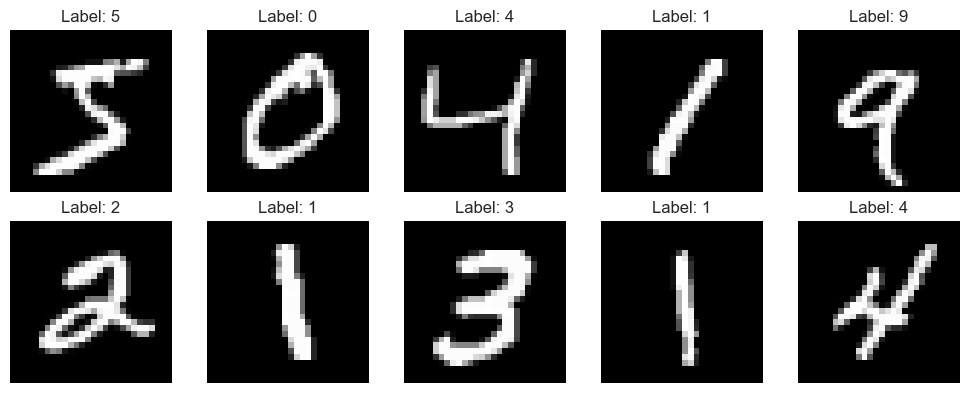

In [2]:
# Load MNIST from Python library (OpenML via scikit-learn)

mnist = fetch_openml('mnist_784', version=1, as_frame=False, parser='auto')
X_full = mnist.data.astype(np.float32)
y_full = mnist.target.astype(np.int32)

print('MNIST loaded:', X_full.shape, y_full.shape)
print('Unique digits:', np.unique(y_full))

# Visual check
fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for i, ax in enumerate(axes.ravel()):
    ax.imshow(X_full[i].reshape(28, 28), cmap='gray')
    ax.set_title(f'Label: {y_full[i]}')
    ax.axis('off')
plt.tight_layout()
plt.show()

## Preprocessing and Task Setup

We convert multiclass MNIST into binary classification:
$$
y=\begin{cases}1 & \text{digit is 0}\\ 0 & \text{otherwise}\end{cases}
$$

Why binary? A single neuron is naturally a binary classifier.

In [3]:
# Normalize and prepare binary labels: digit 0 vs not 0

X = X_full / 255.0
y = (y_full == 0).astype(np.float32).reshape(-1, 1)

# Stratified split to preserve class ratio
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
 )

# Optional subsample so notebook stays fast on most machines
train_limit = 12000
test_limit = 3000
X_train = X_train[:train_limit]
y_train = y_train[:train_limit]
X_test = X_test[:test_limit]
y_test = y_test[:test_limit]

print('Train:', X_train.shape, y_train.shape)
print('Test :', X_test.shape, y_test.shape)
print('Train positive ratio (digit 0):', round(float(y_train.mean()), 4))
print('Test positive ratio (digit 0):', round(float(y_test.mean()), 4))

Train: (12000, 784) (12000, 1)
Test : (3000, 784) (3000, 1)
Train positive ratio (digit 0): 0.0932
Test positive ratio (digit 0): 0.0913


## Manual Single-Neuron Training with Different Activations

Neuron equation:
$$
z = XW + b
$$

We train the same neuron with these activations and compare outcomes.

For differentiable activations, we use gradient descent with MSE loss.
For binary step, we use a perceptron-style update rule.

In [4]:
activations = ['binary_step', 'sigmoid', 'tanh', 'relu', 'leaky_relu']

learning_rate = 0.08
epochs = 45
alpha_leaky = 0.01

results = {}

for act in activations:
    W = np.zeros((X_train.shape[1], 1), dtype=np.float32)
    b = 0.0

    train_loss_history = []
    test_loss_history = []
    train_acc_history = []
    test_acc_history = []

    for epoch in range(epochs):
        z_train = X_train @ W + b

        if act == 'binary_step':
            a_train = (z_train >= 0).astype(np.float32)
            err = y_train - a_train
            dW = -(X_train.T @ err) / X_train.shape[0]
            db = -np.mean(err)
            W -= learning_rate * dW
            b -= learning_rate * db

        else:
            if act == 'sigmoid':
                a_train = 1.0 / (1.0 + np.exp(-np.clip(z_train, -30, 30)))
                da_dz = a_train * (1.0 - a_train)
            elif act == 'tanh':
                a_train = np.tanh(z_train)
                da_dz = 1.0 - (a_train ** 2)
            elif act == 'relu':
                a_train = np.maximum(0.0, z_train)
                da_dz = (z_train > 0).astype(np.float32)
            elif act == 'leaky_relu':
                a_train = np.where(z_train > 0, z_train, alpha_leaky * z_train)
                da_dz = np.where(z_train > 0, 1.0, alpha_leaky).astype(np.float32)

            diff = a_train - y_train
            dz = (2.0 / X_train.shape[0]) * diff * da_dz
            dW = X_train.T @ dz
            db = np.sum(dz)

            W -= learning_rate * dW
            b -= learning_rate * db

        z_train_eval = X_train @ W + b
        z_test_eval = X_test @ W + b

        if act == 'binary_step':
            a_train_eval = (z_train_eval >= 0).astype(np.float32)
            a_test_eval = (z_test_eval >= 0).astype(np.float32)
        elif act == 'sigmoid':
            a_train_eval = 1.0 / (1.0 + np.exp(-np.clip(z_train_eval, -30, 30)))
            a_test_eval = 1.0 / (1.0 + np.exp(-np.clip(z_test_eval, -30, 30)))
        elif act == 'tanh':
            a_train_eval = np.tanh(z_train_eval)
            a_test_eval = np.tanh(z_test_eval)
        elif act == 'relu':
            a_train_eval = np.maximum(0.0, z_train_eval)
            a_test_eval = np.maximum(0.0, z_test_eval)
        elif act == 'leaky_relu':
            a_train_eval = np.where(z_train_eval > 0, z_train_eval, alpha_leaky * z_train_eval)
            a_test_eval = np.where(z_test_eval > 0, z_test_eval, alpha_leaky * z_test_eval)

        train_loss = np.mean((a_train_eval - y_train) ** 2)
        test_loss = np.mean((a_test_eval - y_test) ** 2)

        if act in ['binary_step', 'sigmoid']:
            train_pred = (a_train_eval >= 0.5).astype(np.float32)
            test_pred = (a_test_eval >= 0.5).astype(np.float32)
        elif act == 'tanh':
            train_pred = (a_train_eval >= 0.0).astype(np.float32)
            test_pred = (a_test_eval >= 0.0).astype(np.float32)
        else:
            train_pred = (a_train_eval >= 0.5).astype(np.float32)
            test_pred = (a_test_eval >= 0.5).astype(np.float32)

        train_acc = np.mean(train_pred == y_train)
        test_acc = np.mean(test_pred == y_test)

        train_loss_history.append(float(train_loss))
        test_loss_history.append(float(test_loss))
        train_acc_history.append(float(train_acc))
        test_acc_history.append(float(test_acc))

    results[act] = {
        'W': W,
        'b': b,
        'train_loss': train_loss_history,
        'test_loss': test_loss_history,
        'train_acc': train_acc_history,
        'test_acc': test_acc_history,
        'test_pred': test_pred.ravel(),
    }

print('Training finished for:', ', '.join(activations))

Training finished for: binary_step, sigmoid, tanh, relu, leaky_relu


In [5]:
# Compare final metrics across activations
summary_rows = []
for act in activations:
    summary_rows.append({
        'activation': act,
        'final_train_loss': results[act]['train_loss'][-1],
        'final_test_loss': results[act]['test_loss'][-1],
        'final_train_acc': results[act]['train_acc'][-1],
        'final_test_acc': results[act]['test_acc'][-1],
    })

summary_df = pd.DataFrame(summary_rows).sort_values('final_test_acc', ascending=False)
display(summary_df)

,activation,final_train_loss,final_test_loss,final_train_acc,final_test_acc
0,binary_step,0.014583,0.014667,0.985417,0.985333
2,tanh,0.371797,0.372951,0.980833,0.981000
1,sigmoid,0.047292,0.045713,0.957083,0.962667
3,relu,0.093167,0.091333,0.906833,0.908667
4,leaky_relu,0.097522,0.095616,0.906833,0.908667


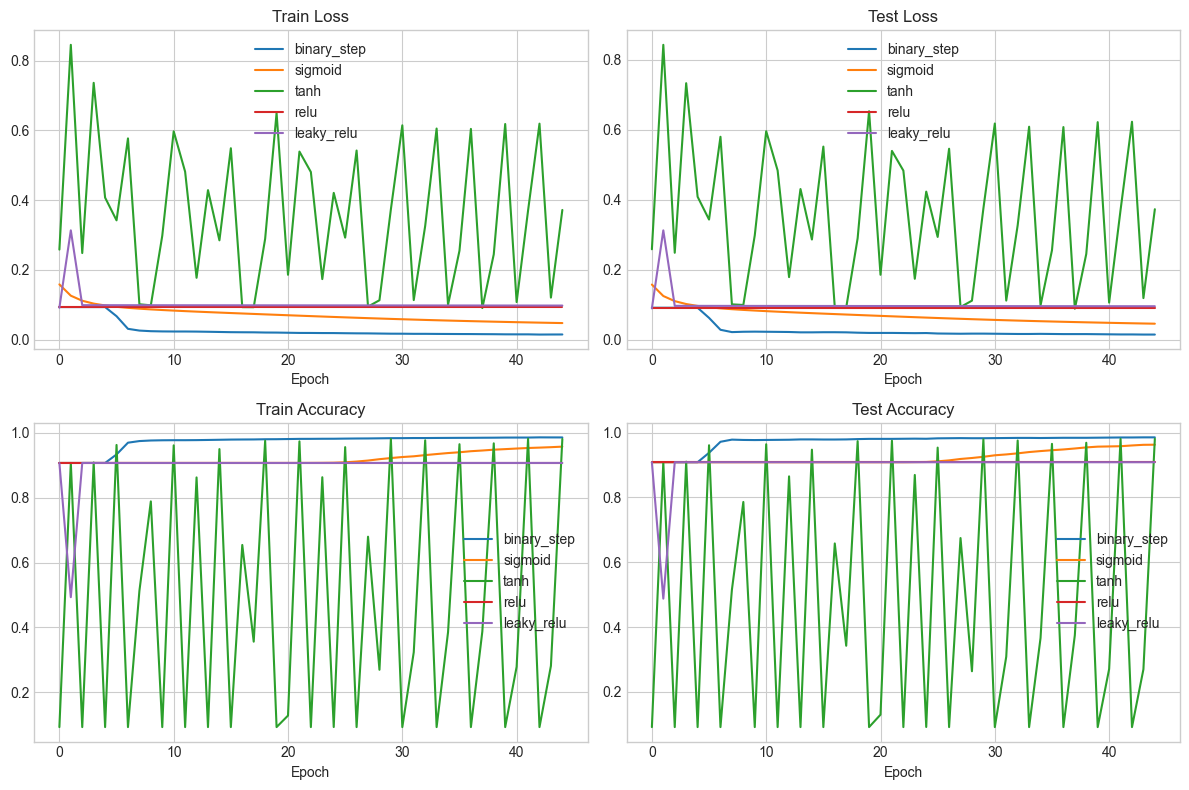

In [6]:
# Plot training curves
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for act in activations:
    axes[0, 0].plot(results[act]['train_loss'], label=act)
    axes[0, 1].plot(results[act]['test_loss'], label=act)
    axes[1, 0].plot(results[act]['train_acc'], label=act)
    axes[1, 1].plot(results[act]['test_acc'], label=act)

axes[0, 0].set_title('Train Loss')
axes[0, 1].set_title('Test Loss')
axes[1, 0].set_title('Train Accuracy')
axes[1, 1].set_title('Test Accuracy')

for ax in axes.ravel():
    ax.set_xlabel('Epoch')
    ax.legend()

plt.tight_layout()
plt.show()

In [7]:
# Confusion matrix + report for best activation on test set
best_activation = summary_df.iloc[0]['activation']
best_pred = results[best_activation]['test_pred']
y_true = y_test.ravel().astype(int)
y_hat = best_pred.astype(int)

cm = confusion_matrix(y_true, y_hat)
report = classification_report(y_true, y_hat, target_names=['not_0', 'is_0'])

print('Best activation:', best_activation)
print('\nClassification report:\n')
print(report)

cm_df = pd.DataFrame(cm, index=['true_not_0', 'true_is_0'], columns=['pred_not_0', 'pred_is_0'])
display(cm_df)

Best activation: binary_step

Classification report:

              precision    recall  f1-score   support

       not_0       0.99      0.99      0.99      2726
        is_0       0.92      0.92      0.92       274

    accuracy                           0.99      3000
   macro avg       0.95      0.96      0.96      3000
weighted avg       0.99      0.99      0.99      3000



,pred_not_0,pred_is_0
true_not_0,2703,23
true_is_0,21,253


## Interpretation and Best-Use Cases

### What this project shows
- A single neuron can detect one digit-vs-rest pattern with limited capacity.
- Differentiable activations generally train more smoothly than hard threshold activation.
- Sigmoid and tanh are natural for binary outputs; ReLU variants may behave less stably for this output setup.

### In practice
- Use **Sigmoid** for binary output neurons.
- Use **Softmax** for full 10-class MNIST classification (multiclass output layer).
- Use **ReLU/Leaky ReLU** mainly in hidden layers of deeper networks, not typically as binary output activation.

### Extension ideas
1. Change target to `digit 1 vs not 1` and compare.
2. Increase epochs and tune learning rate per activation.
3. Move from single neuron to one hidden layer and compare gain in accuracy.